In [1]:
import importlib
import copy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE, SMOTENC
from imblearn.under_sampling import EditedNearestNeighbours
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, recall_score, precision_score, f1_score,
                              confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, auc)

In [2]:
import set_paths
import src.utils as utils
import src.models_tools as mt

In [3]:
data = pd.read_csv(r'..\data\clean.csv')
features = data.iloc[:, 1:]
target = data.iloc[:, 0]
n_splits = 5
seed = 42
fold_maker = StratifiedKFold(n_splits= n_splits, shuffle= True, random_state= seed)
metrics = [accuracy_score, recall_score, precision_score, f1_score]

## Como se estableció en el notebook anterior, las clases están muy desbalanceadas. Se probará un modelo sin resamplear los datos como BaseLine, de arquitectura SVM, con pesos de clase inversamente proporcionales a sus frecuencias

In [4]:
def fold_eval_metrics(y_test: np.array, y_pred: np.array, y_proba: np.array,
                      metrics_dict: dict[list], 
                      roc_dict: dict[list],
                      prc_dict: dict[list], 
                      metrics:list = metrics,):

    for i, metric_name in enumerate(metrics_dict.keys()):
        metric_value = metrics[i](y_test, y_pred)
        metrics_dict[metric_name].append(metric_value)
    #Calculamos las curvas ROC y PRC:
        #ROC
    roc = roc_curve(y_test, y_proba)
    for i, key in enumerate(roc_dict.keys()):
        roc_dict[key].append(roc[i])

        #PRC
    prc = precision_recall_curve(y_test, y_proba)
    for i, key in enumerate(prc_dict.keys()):
        prc_dict[key].append(prc[i])

In [5]:
bl_svc_metrics_eval = copy.deepcopy(utils.metrics_eval)
bl_svc_roc = copy.deepcopy(utils.roc_eval)
bl_svc_prc = copy.deepcopy(utils.prc_eval)

for train_index, test_index in fold_maker.split(features, target):
    #train-test split:
    x_trn, y_trn = features.iloc[train_index], target.iloc[train_index]
    x_test, y_test = features.iloc[test_index], target.iloc[test_index]
    #Definimos los objetos que escalan:
    scaler = MinMaxScaler()
    #Reescalamos:
    x_trn_scld = scaler.fit_transform(x_trn)
    x_test_scld = scaler.transform(x_test)
    #Definimos el modelo (svc):
    svc = SVC(kernel = "rbf", random_state= seed, probability= True, class_weight= "balanced")
    #Entrenamos el modelo:
    svc.fit(x_trn_scld, y_trn)
    #Usamos el modelo para predecir:
    y_pred = svc.predict(x_test_scld)
    y_proba = svc.predict_proba(x_test_scld)[:, 1]
    #Calculamos las métricas:
    fold_eval_metrics(y_test = y_test, y_pred = y_pred, y_proba = y_proba, 
                      metrics_dict= bl_svc_metrics_eval,
                      roc_dict= bl_svc_roc,
                      prc_dict = bl_svc_prc)

In [6]:
bl_svc_metric_mean = mt.metrics_stats(bl_svc_metrics_eval)
print("Métricas promedio para el SVM base:")
bl_svc_metric_mean.head()

Métricas promedio para el SVM base:


,Métrica,Promedio,Desv. Std.
0,accuracy,0.8582,0.0160
1,recall,0.8273,0.0490
2,precision,0.1650,0.0102
3,f1,0.2746,0.0122


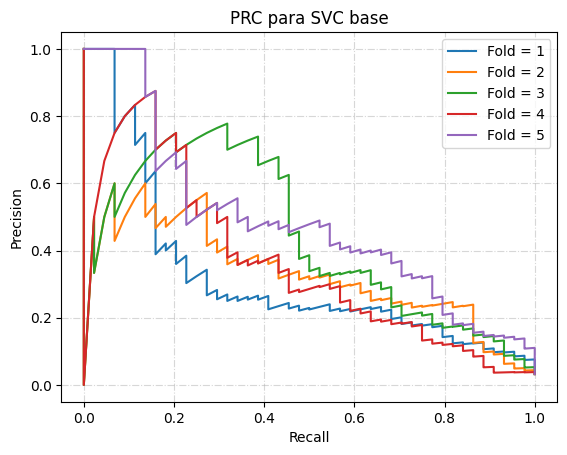

In [7]:
recall, precision = bl_svc_prc["recall"], bl_svc_prc["precision"]
plt.title("PRC para SVC base")
for i in range(5):
    plt.plot(recall[i], precision[i], label = f"Fold = {i+1}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(linestyle = "dashdot", alpha = 0.5)
plt.legend()

In [8]:

metrics_eval = {"accuracy": [], "recall": [], "precision": [], "f1": []}
roc = {"fpr": [], "tpr": [], "thresholds": []}
prc = {"precision": [], "recall": [], "thresholds": []}
for train_index, test_index in fold_maker.split(features, target):
    #train-test split:
    x_trn, y_trn = features.iloc[train_index], target.iloc[train_index]
    x_test, y_test = features.iloc[test_index], target.iloc[test_index]
    #Definimos los objetos que escalan y resamplan:
    scaler = MinMaxScaler()
    smote = SMOTE(sampling_strategy= 0.45, k_neighbors= 3)
    enn = EditedNearestNeighbours(sampling_strategy= "majority", n_neighbors= 3)
    smote_enn = SMOTEENN(smote= smote, enn= enn, random_state= seed)
    #Reescalamos:
    x_trn_scld = scaler.fit_transform(x_trn)
    x_test_scld = scaler.transform(x_test)
    #Resampleamos:
    x_trn_res, y_trn_res = smote_enn.fit_resample(x_trn_scld, y_trn)
    #Definimos el modelo(svc):
    svc = SVC(kernel = "rbf", random_state= seed, probability= True)
    #Entrenamos el modelo:
    svc.fit(x_trn_res, y_trn_res)
    #Usamos el modelo para predecir:
    y_pred = svc.predict(x_test_scld)
    y_proba = svc.predict_proba(x_test_scld)[:, 1]
    #Calculamos las métricas:
    for i, metric_name in enumerate(metrics_eval.keys()):
        metric_value = metrics[i](y_test, y_pred)
        metrics_eval[metric_name].append(metric_value)
    #Calculamos las curvas ROC y PRC:
    fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)
    precision, recall, prc_thresholds = precision_recall_curve(y_test, y_proba)


In [9]:
for metric_name in metrics_eval.keys():
    print(f"{metric_name}: {np.mean(metrics_eval[metric_name])} +- {np.std(metrics_eval[metric_name])}")

accuracy: 0.9036499828952437 +- 0.012039261599988247
recall: 0.7318181818181819 +- 0.07793830999764659
precision: 0.21369498005064896 +- 0.011651591237604638
f1: 0.32943115208811724 +- 0.009419171136293451


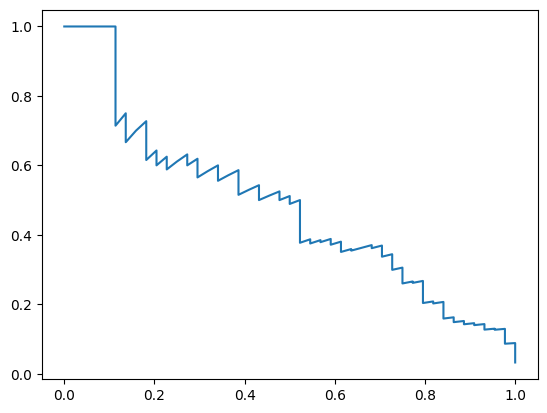

In [10]:
plt.plot(recall, precision)

In [11]:
x_trn_resampled = []
for train_index, test_index in fold_maker.split(features, target):
    #train-test split:
    x_trn, y_trn = features.iloc[train_index], target.iloc[train_index]
    x_test, y_test = features.iloc[test_index], target.iloc[test_index]
    #Definimos los objetos que escalan y resamplan:
    scaler = MinMaxScaler()
    smote = SMOTE(sampling_strategy= 0.45, k_neighbors= 3)
    enn = EditedNearestNeighbours(sampling_strategy= "majority", n_neighbors= 200)
    smote_enn = SMOTEENN(smote= smote, enn= enn, random_state= seed)
    #Reescalamos:
    x_trn_scld = scaler.fit_transform(x_trn)
    x_test_scld = scaler.transform(x_test)
    #Resampleamos:
    x_trn_res, y_trn_res = enn.fit_resample(x_trn_scld, y_trn)
    x_trn_resampled.append((x_trn_res, y_trn_res))

In [12]:
for i in range(5):
    print(x_trn_resampled[i][1].value_counts())

Bankrupt?
0    317
1    176
Name: count, dtype: int64
Bankrupt?
0    236
1    176
Name: count, dtype: int64
Bankrupt?
0    507
1    176
Name: count, dtype: int64
Bankrupt?
0    297
1    176
Name: count, dtype: int64
Bankrupt?
0    317
1    176
Name: count, dtype: int64
